# Semantic Segmentation

## Convolution
In foundational semantic segmentation at the bottom network, fully connected layers are discarded, and convolution serves as the fundamental building block:

- With local receptive fields and weight sharing, convolution is well-suited for spatial feature extraction of images.
- It acts as the basic operator for subsequent downsampling, atrous convolution and feature extraction.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import roi_align

In [2]:
# Input：batch=1, channel=3(RGB), height=32, width=32
x = torch.randn(1, 3, 32, 32)

# Standard convolution for semantic segmentation（Conv + BN + ReLU）
conv = nn.Conv2d(
    in_channels=3,
    out_channels=16,  # extract 16 features
    kernel_size=3,    # 3x3 receptive field
    padding=1         # keep size unchanged
)

# backwards
out = conv(x)
print("Convolution Input Size:", x.shape)    # torch.Size([1, 3, 32, 32])
print("Convolution Output Size:", out.shape)  # torch.Size([1, 16, 32, 32])

Convolution Input Size: torch.Size([1, 3, 32, 32])
Convolution Output Size: torch.Size([1, 16, 32, 32])


## Downsampling & Upsampling
**Standard Architecture of Segmentation Networks**

- Downsampling: Implemented via pooling or strided convolution. It shrinks feature maps, extracts high-level semantics, reduces parameters and enlarges receptive fields, at the cost of losing edge details and spatial location information.
- Upsampling: Adopts deconvolution, interpolation or transposed convolution. It restores low-resolution semantic features to the original image resolution and achieves pixel-wise output.

> Relationship: Downsampling first extracts semantic information, then upsampling recovers spatial resolution. This is the fundamental backbone of FCN, U-Net and SegNet.

In [3]:
x = torch.randn(1, 16, 32, 32)

# ================= Downsampling (1/2) =================
downsample = nn.MaxPool2d(2)  # Max pooling Downsampling
x_down = downsample(x)
print("Downsampling:", x_down.shape)  # torch.Size([1,16,16,16])

# ================= Upsampling (2x) =================
upsample = nn.Upsample(scale_factor=2, mode='bilinear')  # Bilinear Upsampling
# nearest：bilinear：trilinear（3D）
x_up = upsample(x_down)
print("Upsampling:", x_up.shape)  # torch.Size([1,16,32,32])

Downsampling: torch.Size([1, 16, 16, 16])
Upsampling: torch.Size([1, 16, 32, 32])


## Image pyramids
**Solving the Multi-scale Problem**

Downsampling performs scale compression only once inside the network.

Image pyramids implement multi-scale processing at the input level: the original image is scaled to multiple resolutions, fed into the network respectively, and the outputs are fused.

- It adapts to the coexistence of large and small objects in semantic segmentation.
- It complements downsampling: one for in-network scaling, the other for external input scaling.

>Relationship: It compensates for the single-scale limitation of downsampling, serving as a classic early scheme for multi-scale perception.


In [4]:
x = torch.randn(1, 3, 64, 64)

# Build Image pyramids（3 scales：ori、1/2、1/4）
pyramid = [
    x,                          # ori-size
    F.interpolate(x, scale_factor=0.5),  # small->1/2
    F.interpolate(x, scale_factor=0.25)  # small->1/4
]

print("Size of pyramid：")
for i, feat in enumerate(pyramid):
    print(f"{i} layer:", feat.shape)

# Output：
# 0layer: torch.Size([1,3,64,64])
# 1layer: torch.Size([1,3,32,32])
# 2layer: torch.Size([1,3,16,16])

Size of pyramid：
0 layer: torch.Size([1, 3, 64, 64])
1 layer: torch.Size([1, 3, 32, 32])
2 layer: torch.Size([1, 3, 16, 16])


## Skip connections
**Compensating for the Fatal Defect of Downsampling**

The deeper the downsampling, the stronger the high-level semantics, yet the more severely spatial details, edges and contours are lost, which cannot be fully recovered by upsampling.

Skip connection: directly fuses high-precision shallow detail features with strong semantic deep features.

Typical implementations: include the skip structure in FCN and the encoder-decoder skip connection in U-Net.

>Relationship：It remedies the spatial information loss caused by downsampling, acting as a critical compensation method to restore upsampling accuracy.

In [5]:
# Shallow features (high resolution, rich in details)
shallow_feat = torch.randn(1, 16, 32, 32)

# Deep features (low resolution, strong semantics)
deep_feat = torch.randn(1, 16, 32, 32)

# Skip connection: concatenation along channel dimension (standard operation of U-Net)
skip_fusion = torch.cat([shallow_feat, deep_feat], dim=1)

print("Shallow:", shallow_feat.shape)
print("Deep:", deep_feat.shape)
print("Skip connection:", skip_fusion.shape)  # torch.Size([1, 32, 32, 32])

Shallow: torch.Size([1, 16, 32, 32])
Deep: torch.Size([1, 16, 32, 32])
Skip connection: torch.Size([1, 32, 32, 32])


## Dilation（Dilated/Atrous Convolution）
**Replacing Downsampling for Efficient Receptive Field Expansion**

Traditional receptive field expansion relies on repeated downsampling and stacked convolutions, which inevitably causes resolution loss.

Atrous convolution: expands the receptive field via dilated intervals without downsampling or shrinking feature maps, while preserving dense pixel features.

Application: ASPP (Atrous Spatial Pyramid Pooling), which replaces image pyramids to implement in-network multi-scale modeling.

>Relations:
>- It partially replaces downsampling, expanding receptive fields while maintaining resolution;
>- As an advanced multi-scale scheme, it is lighter and end-to-end trainable compared with image pyramids.

In [6]:
x = torch.randn(1, 16, 32, 32)

# Standard convolution：receptive field 3x3
conv_normal = nn.Conv2d(16,16,kernel_size=3,padding=1)

# Atrous convolution：dilation rate = 2, equivalent receptive field 5×5, size unchanged
conv_dilation = nn.Conv2d(16,16,kernel_size=3,padding=2,dilation=2)

out_normal = conv_normal(x)
out_dilation = conv_dilation(x)

print("Standard convolution output:", out_normal.shape)   # [1,16,32,32]
print("Atrous convolution:", out_dilation.shape)  # [1,16,32,32] size unchaged，receptive field bigger

Standard convolution output: torch.Size([1, 16, 32, 32])
Atrous convolution: torch.Size([1, 16, 32, 32])


## ROI Align
**Pixel-level Alignment Precision Optimization for Segmentation Tasks**

All aforementioned modules address holistic semantic segmentation.

ROIAlign is designed for instance segmentation and detection-segmentation joint tasks (Mask R-CNN).
- It resolves pixel misalignment caused by integer quantization in conventional ROI Pooling
- And precisely aligns ROI regions between feature maps and original images via floating-point interpolation.

>Relations: The basic modules serve for general semantic segmentation, while ROIAlign acts as an advanced engineering optimization technique for instance segmentation and high-precision pixel alignment.


In [7]:
# Simulate feature map：1 map，16 channel，size 32x32
features = torch.randn(1, 16, 32, 32)

# Simulate ROI region：[Pixel Index, x1, y1, x2, y2]
rois = torch.tensor([[0, 0, 0, 15, 15.]])  # region

# ROI Align：Pool arbitrary regions into fixed 7×7 features,precise alignment
roi_out = roi_out = roi_align(input=features, boxes=rois, output_size=(7,7), spatial_scale=1.0)

print("ROI Align Output:", roi_out.shape)  # torch.Size([1, 16, 7, 7])

ROI Align Output: torch.Size([1, 16, 7, 7])


## A Sample:Mini U-Net for Semantic Segmentation
**Core logic**: Encoder (downsampling + convolution + atrous convolution) → skip connection → decoder (upsampling) → ROI Align demonstration


In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

class MiniUNet(nn.Module):
    def __init__(self, num_classes=2):  # Simplified to 2-class segmentation (background + target)
        super(MiniUNet, self).__init__()
        
        # 1. Convolution: Basic feature extraction
        # Encoder: Downsampling + Convolution (with dilated convolution)
        self.conv1 = nn.Sequential(  # Shallow convolution: Extract fine details
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(  # Deep convolution: Extract semantic features
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        # 2. Downsampling: Reduce size, enhance semantics
        self.downsample = nn.MaxPool2d(2, stride=2)
        
        # 5. Dilation: Expand receptive field without losing resolution
        self.dilated_conv = nn.Conv2d(32, 32, kernel_size=3, padding=2, dilation=2)
        
        # 2. Upsampling: Restore feature map size
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        # Decoder: Upsampling + Convolution
        self.deconv1 = nn.Sequential(
            nn.Conv2d(48, 16, kernel_size=3, padding=1),  # 48 = 32 (deep) + 16 (shallow, skip connection)
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Conv2d(16, num_classes, kernel_size=1)  # Final per-pixel prediction
        
    def forward(self, x):
        # ------------ Encoder: Downsampling + Convolution + Dilated Convolution ------------
        # Shallow features (rich details, high resolution)
        x1 = self.conv1(x)
        print("1. Shape after shallow conv (detail features):", x1.shape)
        
        # Downsampling
        x_down = self.downsample(x1)
        print("2. Shape after downsampling (enhanced semantics, reduced size):", x_down.shape)
        
        # Deep convolution + dilated convolution (enlarge receptive field)
        x2 = self.conv2(x_down)
        x_dilated = self.dilated_conv(x2)
        print("5. Shape after dilated conv (larger receptive field, same size):", x_dilated.shape)
        
        # ------------ 3. Image pyramids: Multi-scale demonstration ------------
        pyramid = [
            x,                          # Original scale
            F.interpolate(x, scale_factor=0.5),  # 1/2 scale
            F.interpolate(x, scale_factor=0.25)  # 1/4 scale
        ]
        print("\n3. Image pyramid shapes:")
        for i, feat in enumerate(pyramid):
            print(f"   Pyramid level {i}:", feat.shape)
        
        # ------------ 4. Skip connections: Fuse shallow + deep features ------------
        x_up = self.upsample(x_dilated)  # Upsample to restore resolution
        print("\n2. Shape after upsampling (restored to shallow size):", x_up.shape)
        skip_fusion = torch.cat([x1, x_up], dim=1)  # Skip connection: concatenate shallow & upsampled deep features
        print("4. Shape after skip connection fusion:", skip_fusion.shape)
        
        # ------------ Decoder: Output segmentation result ------------
        x_out = self.deconv1(skip_fusion)
        x_final = self.final_conv(x_out)
        print("\nFinal segmentation output shape (per-pixel):", x_final.shape)
        
        # ------------ 6. ROI Align: Pixel-aligned feature extraction for instance segmentation ------------
        # Simulate ROI boxes (candidate object regions)
        rois = torch.tensor([[0, 8, 8, 24, 24.]])  # [img_idx, x1, y1, x2, y2]
        roi_out = roi_align(x1, rois, output_size=(7,7), spatial_scale=1.0)
        print("6. ROI Align output shape (aligned region features):", roi_out.shape)
        
        return x_final

Input image shape (batch, channels, height, width): torch.Size([1, 3, 32, 32])
1. Shape after shallow conv (detail features): torch.Size([1, 16, 32, 32])
2. Shape after downsampling (enhanced semantics, reduced size): torch.Size([1, 16, 16, 16])
5. Shape after dilated conv (larger receptive field, same size): torch.Size([1, 32, 16, 16])

3. Image pyramid shapes:
   Pyramid level 0: torch.Size([1, 3, 32, 32])
   Pyramid level 1: torch.Size([1, 3, 16, 16])
   Pyramid level 2: torch.Size([1, 3, 8, 8])

2. Shape after upsampling (restored to shallow size): torch.Size([1, 32, 32, 32])
4. Shape after skip connection fusion: torch.Size([1, 48, 32, 32])

Final segmentation output shape (per-pixel): torch.Size([1, 2, 32, 32])
6. ROI Align output shape (aligned region features): torch.Size([1, 16, 7, 7])


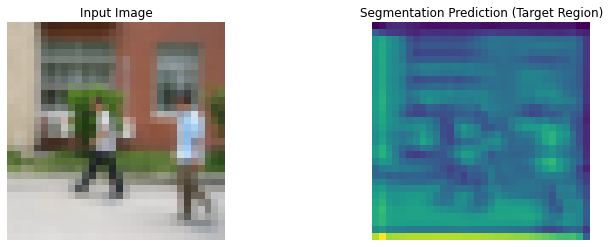

In [25]:
# 1. Dummy input: batch=1, 3 channels (RGB), 32x32 resolution (lightweight for fast demo)
#x = torch.randn(1, 3, 32, 32)
img = Image.open("FudanPed00001.png").convert("RGB")
transform = transforms.Compose([
    transforms.Resize((32, 32)),  
    transforms.ToTensor()         
])
x = transform(img).unsqueeze(0)
print("Input image shape (batch, channels, height, width):", x.shape)
print("="*60)



# 2. Initialize the network
model = MiniUNet(num_classes=2)
model.eval()  # Evaluation mode (no training, just forward pass)

# 3. Forward pass (run all modules and print shape at each step)
with torch.no_grad():  # Disable gradient computation for speed
    output = model(x)

# 4. Optional: Simple visualization (clear for presentation)
plt.figure(figsize=(12, 4))
# Show dummy input (convert channel order: CxHxW → HxWxC)
plt.subplot(1, 2, 1)
plt.imshow(x[0].permute(1, 2, 0).detach().numpy())
plt.title("Input Image")
plt.axis('off')
# Show segmentation prediction (select one class)
plt.subplot(1, 2, 2)
plt.imshow(output[0, 0].detach().numpy())
plt.title("Segmentation Prediction (Target Region)")
plt.axis('off')
plt.show()

In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np

# ============ Dataset for PennFudanPed ============
class PennFudanDataset(Dataset):
    def __init__(self, root, target_size=(256, 256)):
        self.root = root
        self.target_size = target_size
        self.imgs = sorted(os.listdir(os.path.join(root, "PNGImages")))
        self.masks = sorted(os.listdir(os.path.join(root, "PedMasks")))
        
    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        image = Image.open(img_path).convert("RGB")
        
        # Load mask (0=background, >0=pedestrian instances)
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        mask = Image.open(mask_path)
        
        # Resize to target size
        image = image.resize(self.target_size, Image.BILINEAR)
        mask = mask.resize(self.target_size, Image.NEAREST)
        
        # Convert to tensor (normalize image to [0,1], mask to binary)
        image = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(np.array(mask) > 0).long()
        
        return image, mask

# ============ MiniUNet Model (same as your original) ============
class MiniUNet(nn.Module):
    def __init__(self, num_classes=2):  # 2-class: background + pedestrian
        super(MiniUNet, self).__init__()
        
        # Encoder: Feature extraction
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        # Downsampling: Reduce size, enhance semantics
        self.downsample = nn.MaxPool2d(2, stride=2)
        
        # Dilated convolution: Expand receptive field
        self.dilated_conv = nn.Conv2d(32, 32, kernel_size=3, padding=2, dilation=2)
        
        # Upsampling: Restore feature map size
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        # Decoder: Fuse features + final prediction
        self.deconv1 = nn.Sequential(
            nn.Conv2d(48, 16, kernel_size=3, padding=1),  # 48 = 32(deep) + 16(shallow)
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Conv2d(16, num_classes, kernel_size=1)
        
    def forward(self, x):
        # Encoder path
        x1 = self.conv1(x)                     # Shallow features (fine details)
        x_down = self.downsample(x1)           # Downsample
        x2 = self.conv2(x_down)                # Deep features (semantic)
        x_dilated = self.dilated_conv(x2)      # Dilated conv (larger receptive field)
        
        # Skip connection + Decoder
        x_up = self.upsample(x_dilated)        # Upsample to shallow size
        skip_fusion = torch.cat([x1, x_up], dim=1)  # Fuse shallow + deep features
        x_out = self.deconv1(skip_fusion)
        x_final = self.final_conv(x_out)       # Per-pixel classification
        
        return x_final

# ============ Loss Function (handles class imbalance) ============
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred_softmax = F.softmax(pred, dim=1)
        pred_foreground = pred_softmax[:, 1, :, :]  # Pedestrian class
        target_foreground = (target == 1).float()
        
        intersection = (pred_foreground * target_foreground).sum()
        dice = (2. * intersection + self.smooth) / (pred_foreground.sum() + target_foreground.sum() + self.smooth)
        return 1 - dice

class CombinedLoss(nn.Module):
    def __init__(self, weight_ce=0.5, weight_dice=0.5):
        super(CombinedLoss, self).__init__()
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice
        self.ce_loss = nn.CrossEntropyLoss()
        self.dice_loss = DiceLoss()
    
    def forward(self, pred, target):
        return self.weight_ce * self.ce_loss(pred, target) + self.weight_dice * self.dice_loss(pred, target)

# ============ Training Function ============
def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.001, device='cuda'):
    model = model.to(device)
    criterion = CombinedLoss(weight_ce=0.4, weight_dice=0.6)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        # ========== Training Phase ==========
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            
            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Statistics
            train_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            train_correct += (pred == masks).sum().item()
            train_total += masks.numel()
        
        # ========== Validation Phase ==========
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                
                val_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                val_correct += (pred == masks).sum().item()
                val_total += masks.numel()
        
        # Update learning rate
        scheduler.step()
        
        # Record history
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return model, history

# ============ Main Function ============
def main():
    # Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Dataset path (change this to your PennFudanPed folder)
    data_root = "./PennFudanPed"
    
    if not os.path.exists(data_root):
        print(f"Error: Dataset not found at {data_root}")
        print("Expected structure:")
        print("  PennFudanPed/")
        print("  ├── PNGImages/")
        print("  └── PedMasks/")
        return
    
    # Create dataset and split
    full_dataset = PennFudanDataset(root=data_root, target_size=(256, 256))
    total = len(full_dataset)
    train_size = int(0.7 * total)
    val_size = int(0.15 * total)
    test_size = total - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size, test_size]
    )
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
    
    print(f"Dataset: {total} images (Train: {train_size}, Val: {val_size}, Test: {test_size})")
    
    # Initialize model
    model = MiniUNet(num_classes=2)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Train model
    print("\n" + "="*60)
    print("Training MiniUNet on PennFudanPed Dataset")
    print("="*60)
    
    trained_model, history = train_model(model, train_loader, val_loader, num_epochs=30, lr=0.001, device=device)
    
    # Save model
    torch.save(trained_model.state_dict(), "fudanped_model.pth")
    print("\nModel saved to 'fudanped_model.pth'")
    
    # Plot training curves
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()
    
    # Optional: Test the model
    test_model(trained_model, test_loader, device)

def test_model(model, test_loader, device='cuda'):
    """Evaluate model on test set"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            _, pred = torch.max(outputs, 1)
            correct += (pred == masks).sum().item()
            total += masks.numel()
    
    accuracy = correct / total
    print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    return accuracy



Using device: cpu
Dataset: 170 images (Train: 118, Val: 25, Test: 27)
Model parameters: 21,426

Training MiniUNet on PennFudanPed Dataset
Epoch [1/30] - Train Loss: 0.6159, Train Acc: 0.7188 | Val Loss: 0.6287, Val Acc: 0.7869
Epoch [2/30] - Train Loss: 0.5361, Train Acc: 0.7967 | Val Loss: 0.5303, Val Acc: 0.8263
Epoch [3/30] - Train Loss: 0.5096, Train Acc: 0.8180 | Val Loss: 0.4862, Val Acc: 0.8373
Epoch [4/30] - Train Loss: 0.4903, Train Acc: 0.8189 | Val Loss: 0.5324, Val Acc: 0.7681
Epoch [5/30] - Train Loss: 0.4651, Train Acc: 0.8298 | Val Loss: 0.4913, Val Acc: 0.7820
Epoch [6/30] - Train Loss: 0.4613, Train Acc: 0.8319 | Val Loss: 0.4589, Val Acc: 0.8230
Epoch [7/30] - Train Loss: 0.4388, Train Acc: 0.8466 | Val Loss: 0.5920, Val Acc: 0.8245
Epoch [8/30] - Train Loss: 0.4598, Train Acc: 0.8347 | Val Loss: 0.4566, Val Acc: 0.8443
Epoch [9/30] - Train Loss: 0.4293, Train Acc: 0.8491 | Val Loss: 0.4630, Val Acc: 0.8426
Epoch [10/30] - Train Loss: 0.4139, Train Acc: 0.8576 | Val L

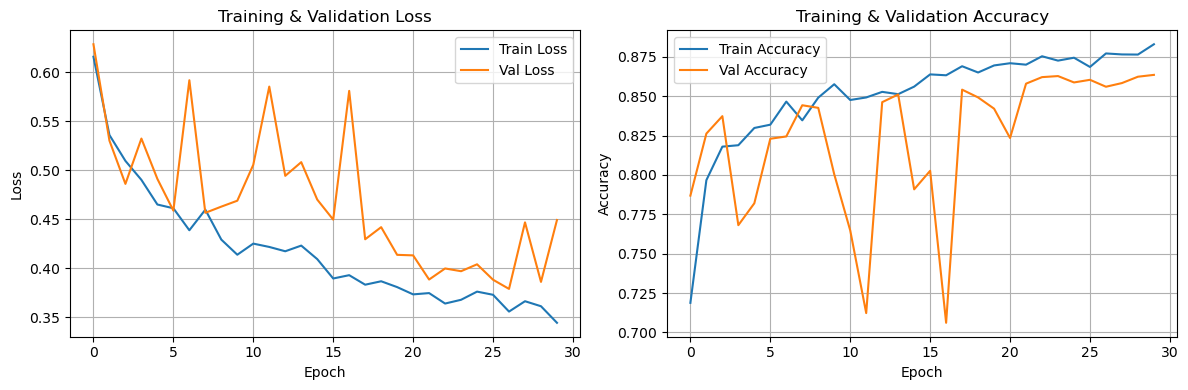


Test Accuracy: 0.8677 (86.77%)


In [17]:
main()